In [1]:
# !pip install pytorch-tabnet

In [1]:
# importing the necessary libs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
from sklearn.preprocessing import LabelEncoder

In [2]:

# cleaning and preparing data

def load_data(file_path):
    data = pd.read_csv(file_path)
    print(data.shape)
    return data

def clean_data(data):
    confidence_mapping = {'l': 1, 'n': 2, 'h': 3}
    if 'confidence' in data.columns:
        data['confidence'] = data['confidence'].map(confidence_mapping)
    daynight_mapping = {'D': 1, 'N': 2}
    if 'daynight' in data.columns:
        data['daynight'] = data['daynight'].map(daynight_mapping)
    data = data.dropna(subset=['frp'])
    return data

def transform_target(data, target):
    transformer = PowerTransformer(method='yeo-johnson')
    data[target] = transformer.fit_transform(data[[target]])
    print(data[target].max())
    print(data[target].min())
    return data, transformer

def scale_features(data, features):
    scaler = MinMaxScaler()
    data[features] = scaler.fit_transform(data[features])
    return data, scaler

def split_data(data, features, target):
    X = data[features]
    y = data[target]
    return train_test_split(X, y, test_size=0.2, random_state=42)

def prepare_data(file_path):
    data = load_data(file_path)
    features = ['latitude', 'longitude', 'brightness', 'bright_t31', 'confidence','daynight']
    target = 'frp'
    data = clean_data(data)
    data, transformer = transform_target(data, target)
    data, scaler = scale_features(data, features)
    X_train, X_test, y_train, y_test = split_data(data, features, target)
    return X_train, X_test, y_train, y_test, scaler, transformer

# loading and splitting the dataset

file_path = 'fire_nrt_J2V-C2_538155(data1).csv'
X_train, X_test, y_train, y_test, scaler, transformer = prepare_data(file_path)


(103070, 14)
3.390296712164582
-3.048532768769535


In [4]:
import joblib
import contextlib
from tqdm.auto import tqdm

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument."""
    
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=1)
            return super().__call__(*args, **kwargs)

    # Store the original callback
    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    
    # Replace it with our patched version
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback

    try:
        yield tqdm_object
    finally:
        # Restore the original callback and close the progress bar
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()


In [ ]:
# Random Forest with hyperparameter tuning using RandomizedSearchCV
param_grid_rf = {
    'n_estimators': [100, 200,300],
    'max_depth': [3, 5],
    'min_samples_split': [2, 4, 5],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [False]
}
rf = RandomForestRegressor(random_state=42)
rf_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,       # Parallel jobs
    verbose=3        # We'll rely on TQDM instead of scikit-learn's verbose
)
num_combinations = 108
folds = 5
total_fits = num_combinations * folds  # 504
with tqdm_joblib(tqdm(total=total_fits, desc="GridSearch Progress")) as progress_bar:
    rf_search.fit(X_train, y_train)
y_pred_rf = rf_search.predict(X_test)
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse= mean_squared_error(y_test, y_pred_rf)
print(rf_r2,rf_mse,rf_mae)

GridSearch Progress:   0%|          | 0/540 [00:00<?, ?it/s]

Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from tqdm import tqdm
from pytorch_tabnet.tab_model import TabNetRegressor

# 1) Convert data to numpy (assuming X_train, y_train, X_test, y_test are defined)
X_train_tab = X_train.to_numpy().astype(np.float32)
y_train_tab = y_train.to_numpy().reshape(-1, 1).astype(np.float32)
X_test_tab = X_test.to_numpy().astype(np.float32)  # For final test evaluation

# 2) Define a small parameter search space (expand as needed)
tabnet_params = [
    {'n_d': 8,  'n_a': 8,  'n_steps': 3, 'gamma': 1.3, 'lambda_sparse': 1e-4},
    {'n_d': 16, 'n_a': 16, 'n_steps': 3, 'gamma': 1.3, 'lambda_sparse': 1e-4},
    {'n_d': 8,  'n_a': 8,  'n_steps': 5, 'gamma': 1.5, 'lambda_sparse': 1e-3},
    {'n_d': 8,  'n_a': 8,  'n_steps': 5, 'gamma': 2.0, 'lambda_sparse': 1e-4},
    {'n_d': 16, 'n_a': 8,  'n_steps': 3, 'gamma': 1.3, 'lambda_sparse': 1e-4},
    {'n_d': 8,  'n_a': 8,  'n_steps': 4, 'gamma': 1.3, 'lambda_sparse': 1e-4},
]

# 3) Define K-Fold cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 4) Variables to track the best model
best_params = None
best_score = -np.inf
best_model = None

# 5) Outer loop: iterate over each hyperparameter set
for params in tqdm(tabnet_params, desc="Hyperparameter Combos"):
    fold_scores = []

    # 6) Inner loop: K-Fold splits
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_tab), 1):
        X_tr, X_val = X_train_tab[train_idx], X_train_tab[val_idx]
        y_tr, y_val = y_train_tab[train_idx], y_train_tab[val_idx]

        # Initialize a TabNet model with the current hyperparameters
        model = TabNetRegressor(**params, verbose=0, seed=42)

        # Train on the fold's training set
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],  # for early stopping monitoring
            max_epochs=50,
            patience=5,
            batch_size=512,
            virtual_batch_size=128,
            num_workers=0
        )

        # Evaluate on the validation fold
        val_preds = model.predict(X_val).squeeze()
        fold_r2 = r2_score(y_val, val_preds)
        fold_scores.append(fold_r2)

    # Compute the average R² across all folds
    avg_score = np.mean(fold_scores)
    print(f"Params: {params} | CV Average R2: {avg_score:.4f}")

    # If this average beats our previous best, update and retrain on full data
    if avg_score > best_score:
        best_score = avg_score
        best_params = params
        best_model = TabNetRegressor(**params, verbose=0, seed=42)
        best_model.fit(
            X_train_tab, y_train_tab,
            max_epochs=50,
            patience=5,
            batch_size=512,
            virtual_batch_size=128,
            num_workers=0
        )

# 7) Evaluate the final best model on the test set
y_pred_test = best_model.predict(X_test_tab).squeeze()
test_r2 = r2_score(y_test, y_pred_test)

print("\n===== Final Results =====")
print(f"Best Params: {best_params}")
print(f"Best CV R2: {best_score:.4f}")
print(f"Test R2: {test_r2:.4f}")


Hyperparameter Combos:   0%|          | 0/6 [00:28<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Evaluation of the models using MAE, MSE and R2 scores
tab_mae=mean_absolute_error(y_test, y_pred_test)
tab_r2=r2_score(y_test, y_pred_test)
tab_mse=mean_squared_error(y_test, y_pred_test)
results_df = pd.DataFrame({
    'Model': ['RF', 'TabNet'],
    'MAE': [rf_mae, tab_mae],
    'MSE': [rf_mse, tab_mse],
    'R²': [rf_r2, tab_r2]
})

print("Model Evaluation Results:")
print(results_df.to_string(index=False, float_format='%.4f'))

# print("RF - MAE:", mae_rf, "MSE:", mse_rf, "R2:", r2_rf)
# print("TabNet - MAE:", mae_tab, "MSE:", mse_tab, "R2:", r2_tab)

Model Evaluation Results:
 Model    MAE    MSE     R²
    RF 0.4637 0.3638 0.6352
TabNet 0.4459 0.3386 0.6605


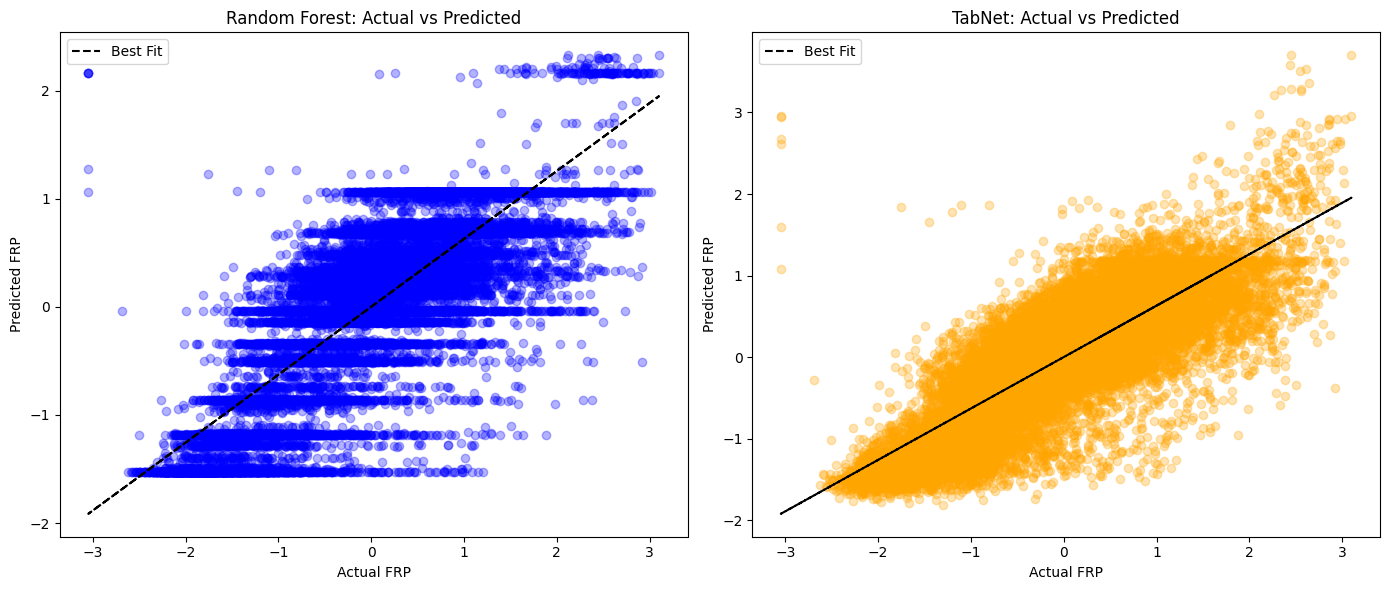

In [ ]:
# Plotting the predictions of the models in comparison
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='blue')
m_rf, b_rf = np.polyfit(y_test, y_pred_rf, 1)
plt.plot(y_test, m_rf * y_test + b_rf, color='black', linestyle='--', label='Best Fit')
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual FRP")
plt.ylabel("Predicted FRP")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_test, alpha=0.3, color='orange')
m_tab, b_tab = np.polyfit(y_test, y_pred_test, 1)
plt.plot(y_test, m_tab * y_test + b_tab, color='black', linestyle='--', label='Best Fit')
plt.legend()
plt.title("TabNet: Actual vs Predicted")
plt.xlabel("Actual FRP")
plt.ylabel("Predicted FRP")
plt.tight_layout()
plt.show()

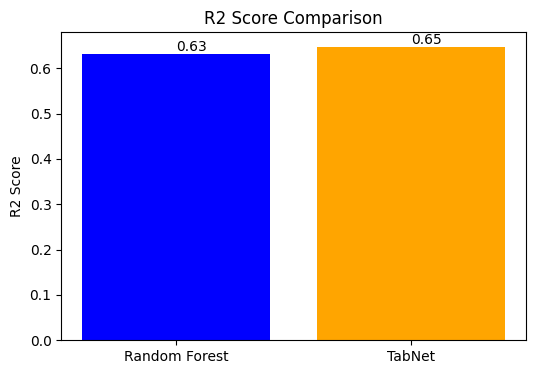

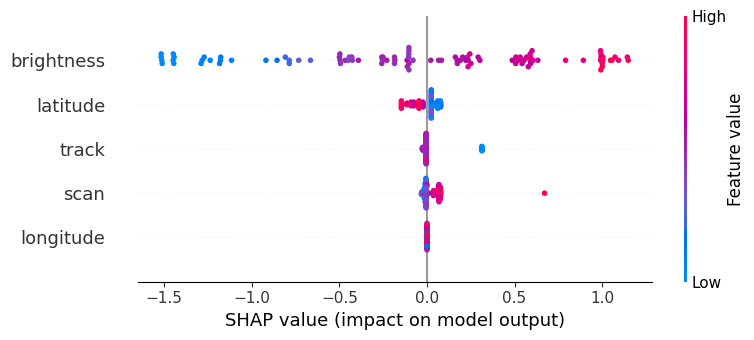

In [ ]:
# Improvement Diagram
plt.figure(figsize=(6,4))
bars = plt.bar(['Random Forest', 'TabNet'], [rf_r2, tab_r2], color=['blue', 'orange'])
plt.title("R2 Score Comparison")
plt.ylabel("R2 Score")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom')
plt.show()



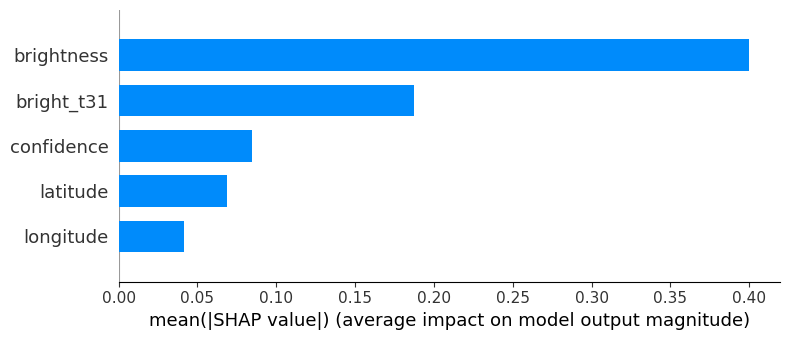

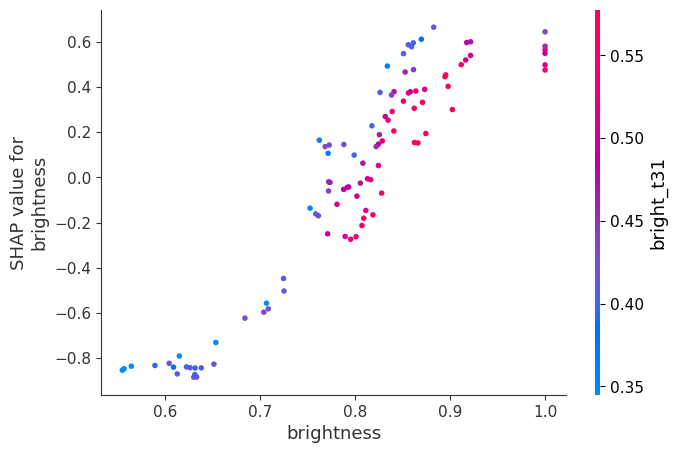

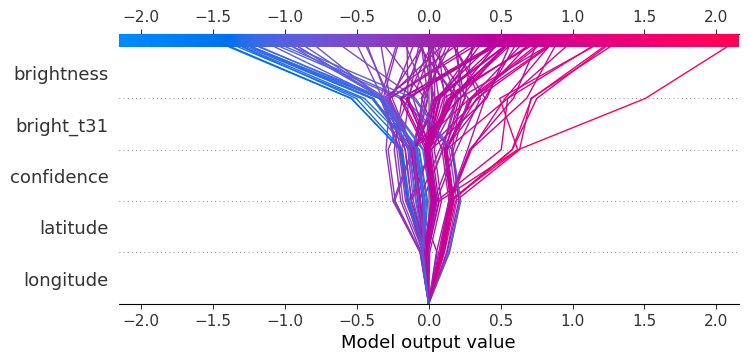

None

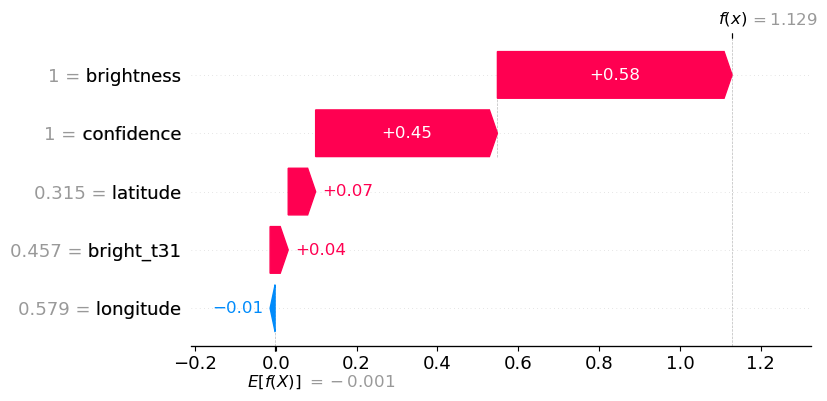

In [ ]:
best_rf=rf_search.best_estimator_
X_sample = X_test.sample(n=100, random_state=42)
# Use TreeExplainer for efficiency with tree-based models
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_sample)
# Summary plot for feature importance
shap.summary_plot(shap_values, X_sample, plot_type="bar")
# Dependence plot for a key feature (e.g., brightness)
shap.dependence_plot("brightness", shap_values, X_sample)
# Pick a single instance from the sample
instance = X_sample.iloc[[0]]
# Calculate SHAP values for that instance
shap_values_instance = explainer.shap_values(instance)
# Generate a force plot
display(shap.decision_plot(explainer.expected_value, shap_values, X_sample))
# Generate an Explanation object by calling the explainer directly
explanation = explainer(X_sample)
single_explanation = explanation[0]
shap.plots.waterfall(single_explanation,max_display=10,show=True)

  0%|          | 0/100 [00:00<?, ?it/s]

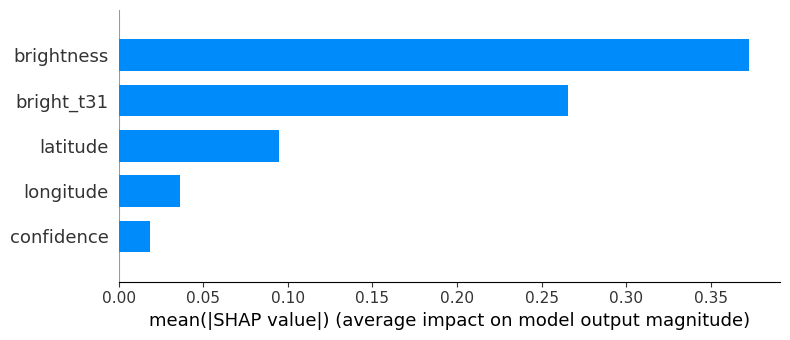

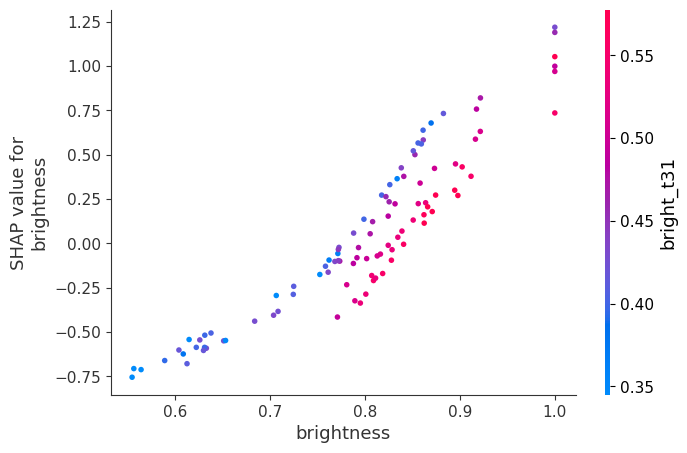

  0%|          | 0/1 [00:00<?, ?it/s]

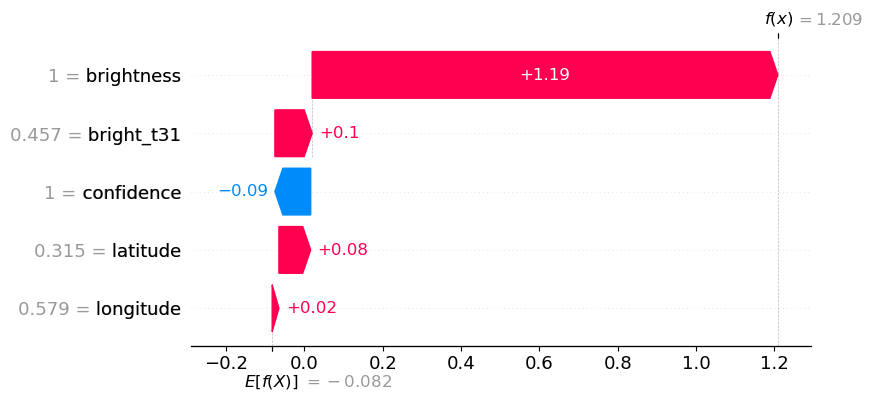

In [ ]:
import shap
import numpy as np

# Suppose best_tabnet_model is trained and X_train_tab, X_test_tab are np arrays or dataframes.
features = ['latitude', 'longitude', 'brightness', 'bright_t31', 'confidence', 'daynight']

X_test_tab_df = pd.DataFrame(X_test_tab, columns=features)
X_train_tab_df = pd.DataFrame(X_train_tab, columns=features)

# Now sample
X_sample_df = X_test_tab_df.sample(n=100, random_state=42)
X_background_df = X_train_tab_df.sample(n=50, random_state=42)

# 3) Define a prediction function (regression)
def tabnet_predict(data):
    return best_model.predict(data).ravel()

# 4) Initialize KernelExplainer
explainer = shap.KernelExplainer(tabnet_predict, X_background_df)

# 5) Compute SHAP values
shap_values = explainer.shap_values(X_sample_df)

# 6) Summary plot
shap.summary_plot(shap_values, X_sample_df, plot_type="bar")

# 7) Dependence plot (example for "brightness" feature)
shap.dependence_plot("brightness", shap_values, X_sample_df)

# 8) Single instance
instance = X_sample_df.iloc[[0]]
shap_values_instance = explainer.shap_values(instance)

# 9) Waterfall plot for single instance
explanation_instance = shap.Explanation(
    values=shap_values_instance, 
    base_values=explainer.expected_value,
    data=instance
)
shap.plots.waterfall(explanation_instance[0], max_display=10, show=True)
